RQ3: Stability and Adaptation

Performance Comparison

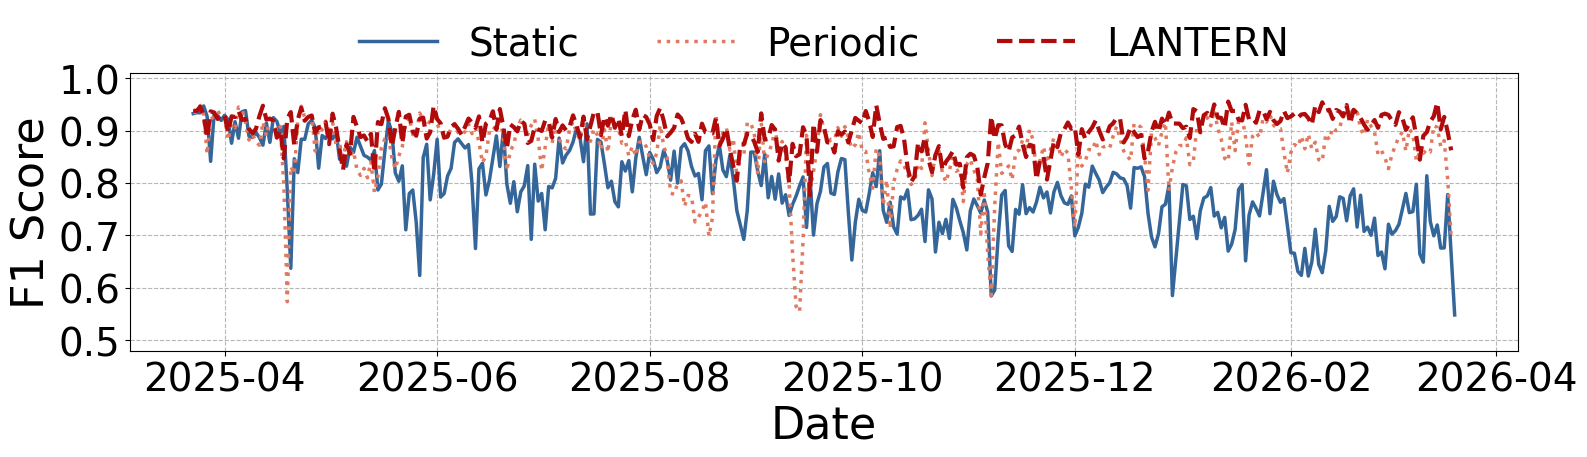

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Style settings ===
font_main = 32
font_extra = 28
figsize = (16, 5)

color_static = "#34669A"
color_adaptive = "#B00A0B"
color_periodic = "#E0795F"

# === 1. Load results ===
static = pd.read_csv("../data/res/static/static8.csv")
dynamic = pd.read_csv("../data/rq3/h8/test_blocks.csv")
periodic = pd.read_csv("../data/rq3/periodic30d/test_blocks.csv")

# === 2. Convert block index to datetime ===
start_time = pd.Timestamp("2025-03-15 00:00:00")

for df in [static, dynamic, periodic]:
    df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === 3. Clean ===
static = static.dropna(subset=["accuracy", "f1_score"])
dynamic = dynamic.dropna(subset=["accuracy", "f1_score"])
periodic = periodic.dropna(subset=["accuracy", "f1_score"])

# === 4. Aggregate per day ===
def daily_mean(df):
    return (
        df.resample("1D", on="datetime")
          .mean(numeric_only=True)
          .reset_index()
    )

static_day = daily_mean(static)
dynamic_day = daily_mean(dynamic)
periodic_day = daily_mean(periodic)

# === 5. Plot (ONLY F1) ===
plt.figure(figsize=figsize)

plt.plot(
    static_day["datetime"],
    static_day["f1_score"],
    color=color_static,
    linewidth=2.5,
    label="Static"
)

plt.plot(
    periodic_day["datetime"],
    periodic_day["f1_score"],
    color=color_periodic,
    linewidth=2.5,
    linestyle=":",
    label="Periodic"
)


plt.plot(
    dynamic_day["datetime"],
    dynamic_day["f1_score"],
    color=color_adaptive,
    linewidth=3.0,
    linestyle="--",
    label="LANTERN"
)


plt.ylabel("F1 Score", fontsize=font_main)
plt.xlabel("Date", fontsize=font_main)

plt.ylim(0.48, 1.01)
plt.yticks(np.arange(0.5, 1.01, 0.1))

plt.grid(alpha=0.9, linestyle="--")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    frameon=False,
    fontsize=font_extra
)

# axis formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=0, fontsize=font_extra)
plt.yticks(fontsize=font_extra)

plt.tight_layout()

plt.savefig(
    "../data/rq3/figs/adaptation_f1_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

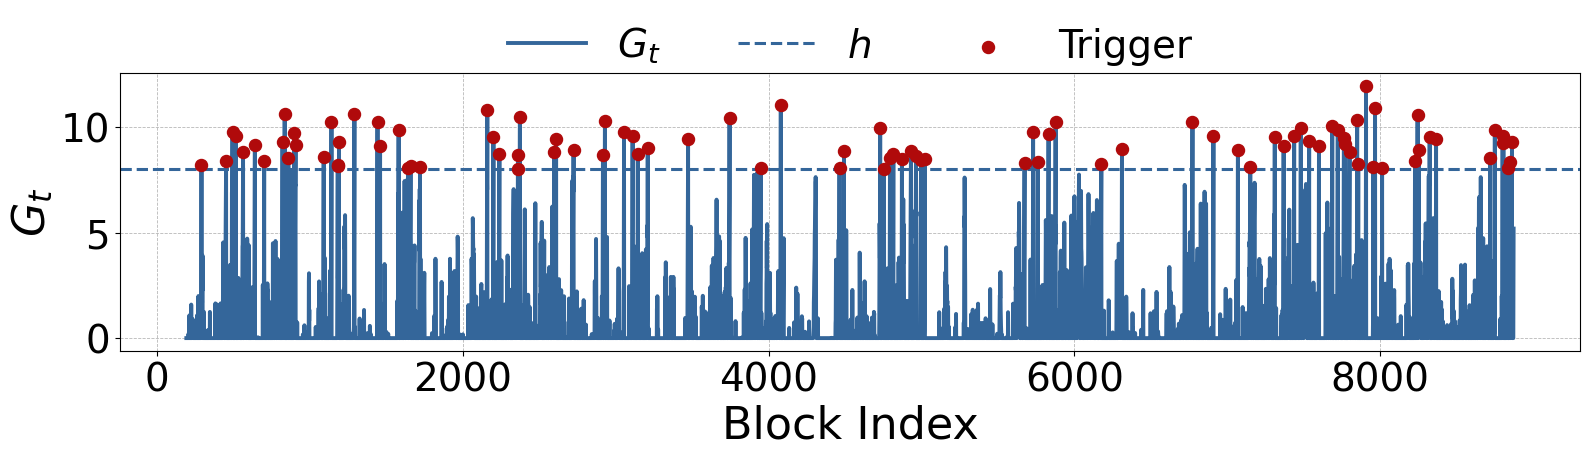

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../LANTERN/data/rq3/h8/test_blocks.csv")

if "data_split" in df.columns:
    df = df[df["data_split"] == "test"].copy()

df = df.sort_values("block_index").reset_index(drop=True)
triggers = df[df["trigger_decision"] == 1].copy()

FIG_SIZE = (16, 5)
FONT_LABEL = 32
FONT_TICK = 28
FONT_LEGEND = 28

COLORS = {
    "g_stat": "#34669A",
    "threshold": "#34669A",
    "trigger": "#B00A0B",
}

h_value = df["h"].dropna().iloc[0]

fig, ax = plt.subplots(figsize=FIG_SIZE)

ax.plot(
    df["block_index"],
    df["g_stat"],
    linewidth=2.8,
    color=COLORS["g_stat"],
    label=r"$G_t$"
)

ax.axhline(
    h_value,
    linestyle="--",
    linewidth=2.2,
    color=COLORS["threshold"],
    label=r"$h$"
)

if len(triggers) > 0:
    ax.scatter(
        triggers["block_index"],
        triggers["g_stat"],
        s=75,
        color=COLORS["trigger"],
        zorder=5,
        label="Trigger"
    )

'''
for x in triggers["block_index"]:
    ax.axvline(x, color=COLORS["trigger"], linestyle=":", linewidth=1.2, alpha=0.25)
'''

ax.set_xlabel("Block Index", fontsize=FONT_LABEL)
ax.set_ylabel(r"$G_t$", fontsize=FONT_LABEL)
ax.tick_params(axis="both", labelsize=FONT_TICK)
ax.grid(alpha=0.9, linestyle="--", linewidth=0.6)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    fontsize=FONT_LEGEND,
    frameon=False
)

plt.tight_layout()
plt.savefig("../data/rq3/figs/rq3_operational_behaviour_dynamic.pdf", bbox_inches="tight")
plt.show()

In [3]:
import pandas as pd
files = {
    "Static": "../../LANTERN/data/res/static/static8.csv",
    "Dynamic": "../../LANTERN/data/rq3/h8/test_blocks.csv",
    "Periodic": "../data/rq3/periodic30d/test_blocks.csv",
}

summary = []

for name, path in files.items():
    df = pd.read_csv(path)

    # Ensure only test data is used (important for your new pipeline)
    if "data_split" in df.columns:
        df = df[df["data_split"] == "test"]

    # Drop missing rows
    df = df.dropna(subset=["accuracy", "f1_score"])

    metrics = {
        "Accuracy_mean": df["accuracy"].mean(),
        "Accuracy_std": df["accuracy"].std(),
        "F1_mean": df["f1_score"].mean(),
        "F1_std": df["f1_score"].std(),
        "Precision_mean": df["precision"].mean(),
        "Recall_mean": df["recall"].mean(),
        "Retrains": max(df["retrain_id"].nunique() - 1, 0)
    }

    summary.append({"Method": name, **metrics})

summary_df = pd.DataFrame(summary)


print("\n=== Overall Performance Summary ===")
print(summary_df.round(4))

summary_df.to_csv("../data/res/adaptive_summary.csv", index=False)


=== Overall Performance Summary ===
     Method  Accuracy_mean  Accuracy_std  F1_mean  F1_std  Precision_mean  \
0    Static         0.8087        0.1149   0.7878  0.1145          0.7971   
1   Dynamic         0.9166        0.0610   0.9005  0.0694          0.9017   
2  Periodic         0.8812        0.0920   0.8646  0.0937          0.8685   

   Recall_mean  Retrains  
0       0.8159         0  
1       0.9083        94  
2       0.8805        12  


#### Monthly Summary

In [4]:
import re
from pathlib import Path, PurePath
# =========================================================
# Helper: Extract YYYY-MM from file path
# =========================================================
def extract_month(path):
    match = re.search(r"(\d{4}-\d{2})-\d{2}", str(path))
    return match.group(1) if match else None

files = {
    "Static": "../../LANTERN/data/res/static/static8.csv",
    "Dynamic": "../../LANTERN/data/rq3/h8/test_blocks.csv",
    "Periodic": "../data/rq3/periodic30d/test_blocks.csv",
}

summary_rows = []

for method, path in files.items():
    df = pd.read_csv(path)
    
    # --- extract date from file path (../data/sequences/YYYY-MM-DD/xxx.csv)
    df["date"] = df["file"].apply(lambda x: Path(x).parts[-2])
    df["month"] = df["date"].str.slice(0, 7)  # YYYY-MM

    grouped = (
        df.groupby("month")
          .agg(
              Accuracy_mean=("accuracy", "mean"),
              Accuracy_std=("accuracy", "std"),
              F1_mean=("f1_score", "mean"),
              F1_std=("f1_score", "std"),
              Precision_mean=("precision", "mean"),
              Precision_std=("precision", "std"),
              Recall_mean=("recall", "mean"),
              Recall_std=("recall", "std"),
              Entropy_mean=("entropy_score", "mean"),
              Entropy_std=("entropy_score", "std"),
              LMT_mean=("lmt_mean_score", "mean"),
              LMT_std=("lmt_mean_score", "std"),
              Retrains=("retrain_id", lambda x: x.nunique() - 1),
          )
          .reset_index()
    )
    grouped["Method"] = method
    summary_rows.append(grouped)

summary_df = pd.concat(summary_rows, ignore_index=True)
summary_df = summary_df[
    ["Method", "month", "Accuracy_mean", "Accuracy_std", "F1_mean", "F1_std",
     "Precision_mean","Precision_std", "Recall_mean", "Recall_std","Entropy_mean", "Entropy_std",
     "LMT_mean", "LMT_std", "Retrains"]
]
summary_df.to_csv("../../LANTERN/data/rq3/monthly_drift_summary.csv", index=False)
print(" Monthly drift + performance summary saved → ../data/rq3/monthly_drift_summary.csv")

# --- Optional: print preview ---
pd.set_option("display.max_rows", None)
print(summary_df.round(4))


 Monthly drift + performance summary saved → ../data/rq3/monthly_drift_summary.csv
      Method    month  Accuracy_mean  Accuracy_std  F1_mean  F1_std  \
0     Static  2025-03         0.9266        0.0500   0.9219  0.0525   
1     Static  2025-04         0.8971        0.0724   0.8824  0.0930   
2     Static  2025-05         0.8496        0.1061   0.8306  0.1081   
3     Static  2025-06         0.8256        0.1126   0.8158  0.1069   
4     Static  2025-07         0.8496        0.0882   0.8266  0.0892   
5     Static  2025-08         0.8630        0.0944   0.8229  0.0994   
6     Static  2025-09         0.8047        0.1023   0.7826  0.1029   
7     Static  2025-10         0.7636        0.0982   0.7446  0.1003   
8     Static  2025-11         0.7616        0.1032   0.7449  0.0946   
9     Static  2025-12         0.7949        0.1006   0.7792  0.0996   
10    Static  2026-01         0.7561        0.1147   0.7396  0.1098   
11    Static  2026-02         0.7425        0.1058   0.7147  0.09

In [5]:
import pandas as pd

df = pd.read_csv("../../LANTERN/data/rq3/h8/test_blocks.csv")

# Keep only test data
if "data_split" in df.columns:
    df = df[df["data_split"] == "test"].copy()

# Total blocks
n_blocks = len(df)

# Triggered blocks
n_triggers = df["trigger_decision"].sum()

# Trigger rate
trigger_rate = n_triggers / n_blocks

print(f"Total blocks: {n_blocks}")
print(f"Triggers: {n_triggers}")
print(f"Trigger rate: {trigger_rate:.4f} ({trigger_rate*100:.2f}%)")

Total blocks: 8680
Triggers: 94
Trigger rate: 0.0108 (1.08%)


##### Triggering Analysis

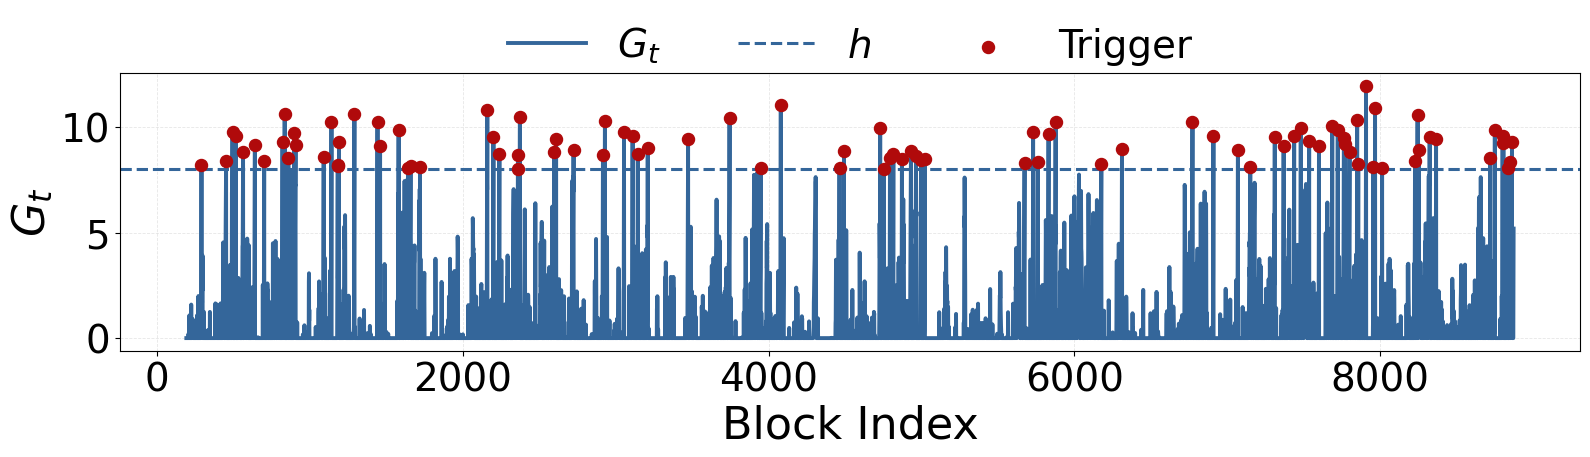

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../LANTERN/data/rq3/h8/test_blocks.csv")

if "data_split" in df.columns:
    df = df[df["data_split"] == "test"].copy()

df = df.sort_values("block_index").reset_index(drop=True)
triggers = df[df["trigger_decision"] == 1].copy()

FIG_SIZE = (16, 5)
FONT_LABEL = 32
FONT_TICK = 28
FONT_LEGEND = 28

COLORS = {
    "g_stat": "#34669A",
    "threshold": "#34669A",
    "trigger": "#B00A0B",
}

h_value = df["h"].dropna().iloc[0]

fig, ax = plt.subplots(figsize=FIG_SIZE)

ax.plot(
    df["block_index"],
    df["g_stat"],
    linewidth=2.8,
    color=COLORS["g_stat"],
    label=r"$G_t$"
)

ax.axhline(
    h_value,
    linestyle="--",
    linewidth=2.2,
    color=COLORS["threshold"],
    label=r"$h$"
)

if len(triggers) > 0:
    ax.scatter(
        triggers["block_index"],
        triggers["g_stat"],
        s=75,
        color=COLORS["trigger"],
        zorder=5,
        label="Trigger"
    )

'''
for x in triggers["block_index"]:
    ax.axvline(x, color=COLORS["trigger"], linestyle=":", linewidth=1.2, alpha=0.25)
'''

ax.set_xlabel("Block Index", fontsize=FONT_LABEL)
ax.set_ylabel(r"$G_t$", fontsize=FONT_LABEL)
ax.tick_params(axis="both", labelsize=FONT_TICK)
ax.grid(alpha=0.3, linestyle="--", linewidth=0.6)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    fontsize=FONT_LEGEND,
    frameon=False
)

plt.tight_layout()
plt.savefig("../data/rq3/figs/rq3_operational_behaviour_dynamic.pdf", bbox_inches="tight")
plt.show()

### Generalisation Test

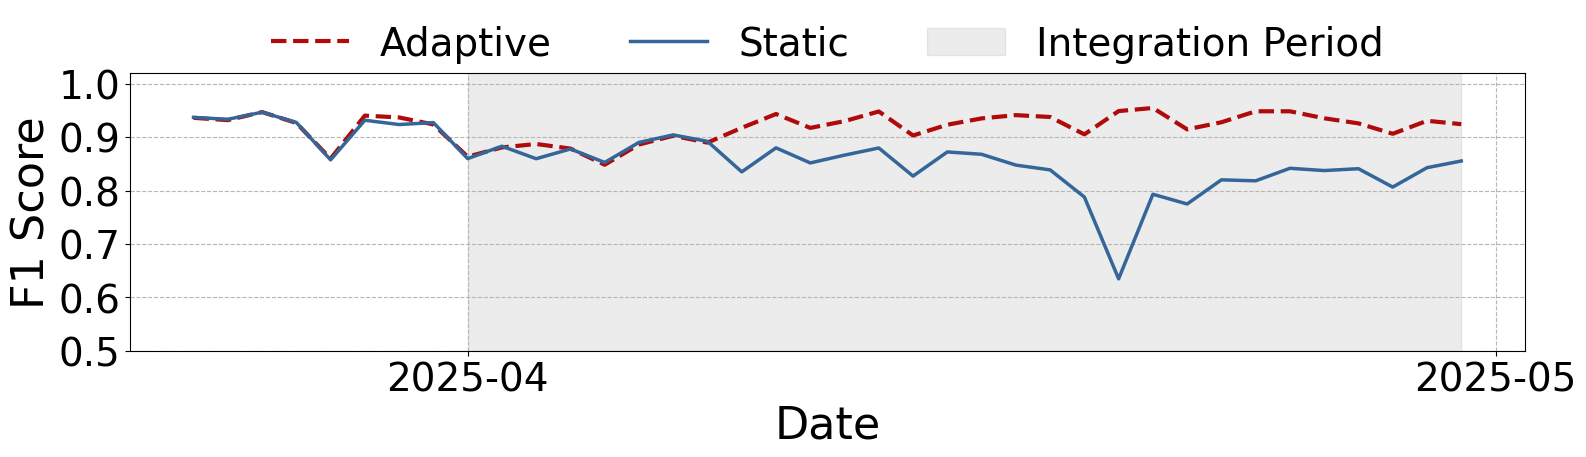

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import numpy as np

# === Style settings ===
font_main = 32
font_extra = 28
figsize = (16, 5)

color_static = "#34669A"
color_adaptive = "#B00A0B"

# === Load ===
static = pd.read_csv("../data/res/generalisation_static/test_blocks.csv")
dynamic = pd.read_csv("../data/res/generalisation/test_blocks.csv")

# === Extract date ===
def extract_date(filepath):
    match = re.search(r'/(\d{4}-\d{2}-\d{2})/', str(filepath))
    return match.group(1) if match else None

static["date"] = pd.to_datetime(static["file"].apply(extract_date))
dynamic["date"] = pd.to_datetime(dynamic["file"].apply(extract_date))

# === Clean ===
static = static.dropna(subset=["f1_score"])
dynamic = dynamic.dropna(subset=["f1_score"])

# === Daily aggregation ===
static_day = (
    static.groupby("date")
    .mean(numeric_only=True)
    .reset_index()
)

dynamic_day = (
    dynamic.groupby("date")
    .mean(numeric_only=True)
    .reset_index()
)

# === XPOT integration window ===
xpot_start = pd.to_datetime("2025-04-01")
xpot_end   = pd.to_datetime("2025-04-30")

# === Trim tail (important for visual clarity) ===
plot_end = pd.to_datetime("2025-04-30")

static_day = static_day[static_day["date"] <= plot_end]
dynamic_day = dynamic_day[dynamic_day["date"] <= plot_end]

# === Plot ===
plt.figure(figsize=figsize)

plt.plot(
    dynamic_day["date"],
    dynamic_day["f1_score"],
    color=color_adaptive,
    linewidth=3.0,
    linestyle="--",
    label="Adaptive"
)

plt.plot(
    static_day["date"],
    static_day["f1_score"],
    color=color_static,
    linewidth=2.5,
    label="Static"
)

# highlight XPOT
plt.axvspan(
    xpot_start,
    xpot_end,
    color="gray",
    alpha=0.15,
    label="Integration Period"
)

# === Labels ===
plt.ylabel("F1 Score", fontsize=font_main)
plt.xlabel("Date", fontsize=font_main)

plt.ylim(0.5, 1.02)
plt.yticks(np.arange(0.5, 1.01, 0.1))

# === Axis formatting ===
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(fontsize=font_extra, rotation=0)
plt.yticks(fontsize=font_extra)

# === Legend ===
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    frameon=False,
    fontsize=font_extra
)

plt.grid(alpha=0.9, linestyle="--")

plt.tight_layout()

plt.savefig(
    "../data/rq3/figs/generalisation_f1_clean.pdf",
    bbox_inches="tight"
)

plt.show()

In [9]:
# === Quick summary ===
def summarise_run(name, df):
    n_blocks = len(df)

    mean_f1 = df["f1_score"].mean() if "f1_score" in df.columns else np.nan
    std_f1 = df["f1_score"].std() if "f1_score" in df.columns else np.nan

    if "trigger_decision" in df.columns:
        n_triggers = int(df["trigger_decision"].fillna(0).sum())
        trigger_rate = n_triggers / n_blocks if n_blocks > 0 else np.nan
    else:
        n_triggers = 0
        trigger_rate = np.nan

    print(f"\n{name}")
    print(f"Blocks: {n_blocks}")
    print(f"Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"Trigger events: {n_triggers}")
    if not np.isnan(trigger_rate):
        print(f"Trigger rate: {trigger_rate:.4%}")

summarise_run("Static", static)
summarise_run("Adaptive", dynamic)


Static
Blocks: 1269
Macro F1: 0.8586 ± 0.0798
Trigger events: 766
Trigger rate: 60.3625%

Adaptive
Blocks: 1269
Macro F1: 0.9003 ± 0.0774
Trigger events: 7
Trigger rate: 0.5516%


In [10]:
# === Compare performance during integration period ===
def summarise_integration_period(name, df, start, end):
    sub = df[(df["date"] >= start) & (df["date"] <= end)].copy()

    mean_f1 = sub["f1_score"].mean()
    std_f1 = sub["f1_score"].std()

    print(f"\n{name} during integration period")
    print(f"Blocks: {len(sub)}")
    print(f"Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

summarise_integration_period("Static", static, xpot_start, xpot_end)
summarise_integration_period("Adaptive", dynamic, xpot_start, xpot_end)


Static during integration period
Blocks: 718
Macro F1: 0.8412 ± 0.0816

Adaptive during integration period
Blocks: 718
Macro F1: 0.9169 ± 0.0650


In [11]:
static_sub = static[(static["date"] >= xpot_start) & (static["date"] <= xpot_end)]
dynamic_sub = dynamic[(dynamic["date"] >= xpot_start) & (dynamic["date"] <= xpot_end)]

static_f1 = static_sub["f1_score"].mean()
dynamic_f1 = dynamic_sub["f1_score"].mean()

print("\nDuring integration period")
print(f"Static Macro F1  : {static_f1:.4f}")
print(f"Adaptive Macro F1: {dynamic_f1:.4f}")
print(f"Gain             : {dynamic_f1 - static_f1:.4f}")


During integration period
Static Macro F1  : 0.8412
Adaptive Macro F1: 0.9169
Gain             : 0.0757


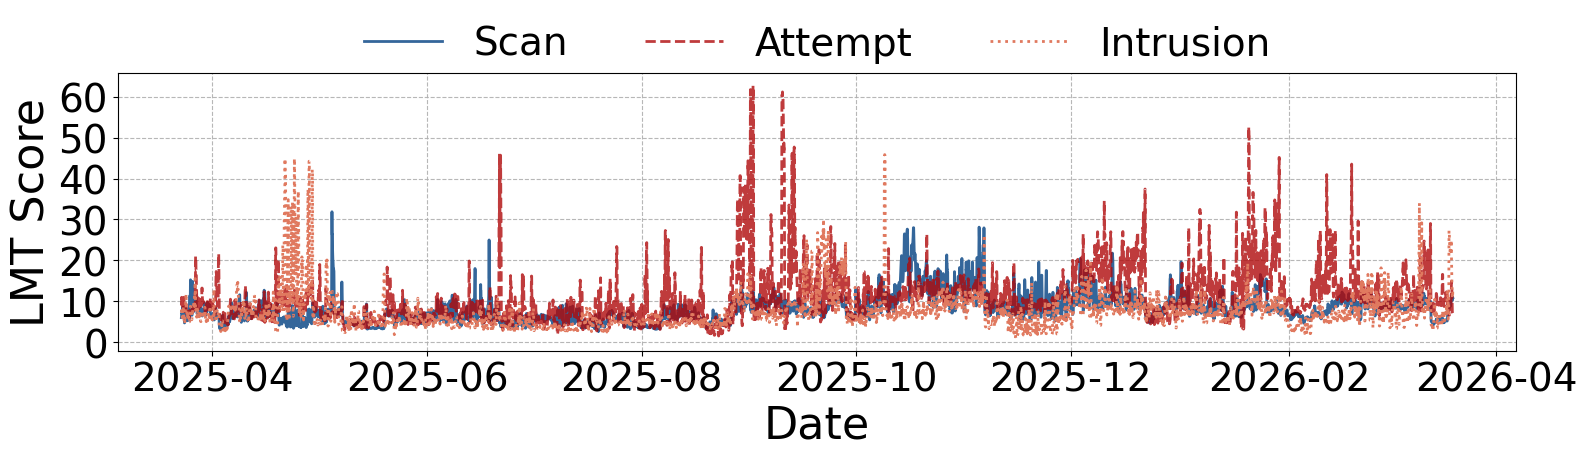

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Load ===
df = pd.read_csv("../data/rq3/h8/test_blocks.csv")
#df = pd.read_csv("../data/res/static/static8.csv")

# convert block index → datetime
start_time = pd.Timestamp("2025-03-15 00:00:00")
df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === Style ===
font_main = 32
font_extra = 28
figsize = (16, 5)

color_attempt = "#B00A0B"
color_intrusion = "#E0795F" 
color_scan = "#34669A" 

# === Optional smoothing ===
window = 6
df["attempt_s"] = df["lmt_attempt_score"].rolling(window, center=True).median()
df["intrusion_s"] = df["lmt_intrusion-control_score"].rolling(window, center=True).median()
df["scan_s"] = df["lmt_scan_score"].rolling(window, center=True).median()

# === Plot ===
plt.figure(figsize=figsize)

plt.plot(
    df["datetime"],
    df["scan_s"],
    color=color_scan,
    linewidth=2.0,
    label="Scan",
)

plt.plot(
    df["datetime"],
    df["attempt_s"],
    color=color_attempt,
    linewidth=2.0,
    linestyle="--",
    label="Attempt",
    alpha=0.8
)

plt.plot(
    df["datetime"],
    df["intrusion_s"],
    color=color_intrusion,
    linewidth=2.0,
    linestyle=":",
    label="Intrusion",
)


plt.ylabel("LMT Score", fontsize=font_main)
plt.xlabel("Date", fontsize=font_main)

plt.grid(alpha=0.9, linestyle="--")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    frameon=False,
    fontsize=font_extra
)

# x-axis formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=0, fontsize=font_extra)
plt.yticks(fontsize=font_extra)

plt.tight_layout()

plt.savefig("lmt_inclass_evolution.pdf", bbox_inches="tight")
plt.show()

Quantative Measures

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import linregress


# === Convert block index to datetime if needed ===
start_time = pd.Timestamp("2025-03-15 00:00:00")
df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === Columns for in class evolution ===
score_cols = {
    "Attempt": "lmt_attempt_score",
    "Intrusion": "lmt_intrusion-control_score",
    "Scan": "lmt_scan_score",
}

# === Helper for robust peak counting ===
def count_peaks_above_threshold(series, threshold):
    s = np.asarray(series, dtype=float)
    count = 0
    for i in range(1, len(s) - 1):
        if s[i] > s[i - 1] and s[i] > s[i + 1] and s[i] > threshold:
            count += 1
    return count

# === Quantitative report ===
rows = []

for label, col in score_cols.items():
    s = df[col].dropna().astype(float).reset_index(drop=True)

    x = np.arange(len(s))
    slope, intercept, r_value, p_value, std_err = linregress(x, s)

    mean_val = s.mean()
    std_val = s.std()
    min_val = s.min()
    max_val = s.max()
    median_val = s.median()

    # early vs late evolution
    n = len(s)
    first_part = s.iloc[: max(1, n // 2)]
    last_part = s.iloc[-max(1, n // 2):]

    early_mean = first_part.mean()
    late_mean = last_part.mean()
    delta_late_early = late_mean - early_mean
    ratio_late_early = late_mean / early_mean if early_mean != 0 else np.nan

    # robust threshold for peaks
    mad = np.median(np.abs(s - median_val))
    peak_threshold = median_val + 3 * mad
    n_peaks = count_peaks_above_threshold(s, peak_threshold)

    rows.append({
        "class": label,
        "n_blocks": int(n),
        "mean": float(mean_val),
        "std": float(std_val),
        "median": float(median_val),
        "min": float(min_val),
        "max": float(max_val),
        "early_mean": float(early_mean),
        "late_mean": float(late_mean),
        "delta_late_early": float(delta_late_early),
        "ratio_late_early": float(ratio_late_early),
        "trend_slope_per_block": float(slope),
        "trend_r": float(r_value),
        "trend_p": float(p_value),
        "peak_threshold": float(peak_threshold),
        "n_peaks": int(n_peaks),
    })

report_df = pd.DataFrame(rows)

# === Optional rounding for display ===
report_display = report_df.copy()
num_cols = report_display.select_dtypes(include=[np.number]).columns
report_display[num_cols] = report_display[num_cols].round(4)

print("\n=== In Class Evolution Report ===")
print(report_display.to_string(index=False))

# === Save ===
report_display.to_csv("inclass_evolution_report.csv", index=False)
print("\nSaved: inclass_evolution_report.csv")


=== In Class Evolution Report ===
    class  n_blocks    mean    std  median    min      max  early_mean  late_mean  delta_late_early  ratio_late_early  trend_slope_per_block  trend_r  trend_p  peak_threshold  n_peaks
  Attempt      8677 11.8259 9.4141  9.4930 1.2578 127.3117      9.8897    13.7575            3.8677            1.3911                 0.0009   0.2463      0.0         19.7769      645
Intrusion      8676  7.9530 6.4356  6.4005 0.8258 152.0377      6.9653     8.9407            1.9754            1.2836                 0.0002   0.0779      0.0         12.8315      621
     Scan      8680  8.4548 4.4073  7.6116 2.4367 152.5638      6.7623    10.1473            3.3850            1.5006                 0.0005   0.2626      0.0         13.7115      431

Saved: inclass_evolution_report.csv


### Add ranges

In [4]:
import pandas as pd
import numpy as np

# === Load ===
df = pd.read_csv("../data/rq3/h8/test_blocks.csv")

start_time = pd.Timestamp("2025-03-15 00:00:00")
df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === Smoothed signals, same as plot ===
window = 6
df["attempt_s"] = df["lmt_attempt_score"].rolling(window, center=True).median()
df["intrusion_s"] = df["lmt_intrusion-control_score"].rolling(window, center=True).median()
df["scan_s"] = df["lmt_scan_score"].rolling(window, center=True).median()


def find_event_ranges(
    data,
    score_col,
    start,
    end,
    method="mad",
    k=2.5,
    q=0.9,
    min_blocks=4,
    bridge_gap=1,
):
    """
    Detect contiguous elevated ranges in a given time region.

    Parameters
    ----------
    score_col : str
        Smoothed score column, e.g. 'attempt_s'
    start, end : str or Timestamp
        Rough date window to search inside
    method : str
        'mad' or 'quantile'
    k : float
        Threshold = median + k * MAD when method='mad'
    q : float
        Threshold = quantile(q) when method='quantile'
    min_blocks : int
        Minimum run length to keep
    bridge_gap : int
        Merge small gaps up to this many blocks
    """
    sub = data[(data["datetime"] >= pd.Timestamp(start)) & (data["datetime"] <= pd.Timestamp(end))].copy()
    sub = sub[["block_index", "datetime", "file", "retrain_id", score_col]].dropna().reset_index(drop=True)

    x = sub[score_col]

    if method == "mad":
        med = x.median()
        mad = np.median(np.abs(x - med))
        thr = med + k * mad
    elif method == "quantile":
        thr = x.quantile(q)
    else:
        raise ValueError("method must be 'mad' or 'quantile'")

    sub["above"] = x > thr

    # bridge small gaps
    if bridge_gap > 0:
        above = sub["above"].values.copy()
        n = len(above)
        i = 0
        while i < n:
            if not above[i]:
                j = i
                while j < n and not above[j]:
                    j += 1
                gap_len = j - i
                left_on = (i - 1 >= 0 and above[i - 1])
                right_on = (j < n and above[j])
                if left_on and right_on and gap_len <= bridge_gap:
                    above[i:j] = True
                i = j
            else:
                i += 1
        sub["above"] = above

    # contiguous runs
    sub["grp"] = (sub["above"] != sub["above"].shift()).cumsum()

    events = []
    for _, g in sub[sub["above"]].groupby("grp"):
        if len(g) < min_blocks:
            continue

        peak_idx = g[score_col].idxmax()
        peak_row = sub.loc[peak_idx]

        events.append({
            "start_time": g["datetime"].iloc[0],
            "end_time": g["datetime"].iloc[-1],
            "start_block": int(g["block_index"].iloc[0]),
            "end_block": int(g["block_index"].iloc[-1]),
            "n_blocks": len(g),
            "peak_time": peak_row["datetime"],
            "peak_block": int(peak_row["block_index"]),
            "peak_score": float(peak_row[score_col]),
            "retrain_ids": sorted(g["retrain_id"].dropna().unique().tolist()),
        })

    events = pd.DataFrame(events)
    return sub, events, thr

In [5]:
# 1. Intrusion around late April
sub_intr_apr, evt_intr_apr, thr_intr_apr = find_event_ranges(
    df,
    score_col="intrusion_s",
    start="2025-04-19",
    end="2025-05-05",
    method="mad",
    k=2.0,
    min_blocks=4,
    bridge_gap=1,
)

# 2. Attempt around late Aug to early Sep
sub_att_sep, evt_att_sep, thr_att_sep = find_event_ranges(
    df,
    score_col="attempt_s",
    start="2025-08-20",
    end="2025-09-20",
    method="mad",
    k=2.0,
    min_blocks=4,
    bridge_gap=1,
)

# 3. Scan around Oct to Nov
sub_scan_octnov, evt_scan_octnov, thr_scan_octnov = find_event_ranges(
    df,
    score_col="scan_s",
    start="2025-10-01",
    end="2025-11-30",
    method="mad",
    k=2.0,
    min_blocks=6,
    bridge_gap=2,
)

# 4. Intrusion around late Jan
sub_intr_jan, evt_intr_jan, thr_intr_jan = find_event_ranges(
    df,
    score_col="intrusion_s",
    start="2026-01-10",
    end="2026-02-05",
    method="mad",
    k=2.0,
    min_blocks=4,
    bridge_gap=1,
)

print("Late April intrusion")
print(evt_intr_apr)
print()

print("Late Aug to early Sep attempt")
print(evt_att_sep)
print()

print("Oct to Nov scan")
print(evt_scan_octnov)
print()

print("Late Jan intrusion")
print(evt_intr_jan)

Late April intrusion
            start_time            end_time  start_block  end_block  n_blocks  \
0  2025-04-20 23:00:00 2025-04-21 02:00:00          887        890         4   
1  2025-04-21 09:00:00 2025-04-21 20:00:00          897        908        12   
2  2025-04-22 09:00:00 2025-04-22 15:00:00          921        927         7   
3  2025-04-23 06:00:00 2025-04-23 11:00:00          942        947         6   
4  2025-04-23 17:00:00 2025-04-23 20:00:00          953        956         4   
5  2025-04-24 03:00:00 2025-04-24 19:00:00          963        979        17   
6  2025-04-25 07:00:00 2025-04-25 13:00:00          991        997         7   
7  2025-04-26 10:00:00 2025-04-26 13:00:00         1018       1021         4   
8  2025-04-28 00:00:00 2025-04-28 05:00:00         1056       1061         6   
9  2025-04-28 10:00:00 2025-04-28 17:00:00         1066       1073         8   
10 2025-04-29 08:00:00 2025-04-29 12:00:00         1088       1092         5   
11 2025-05-03 10:00

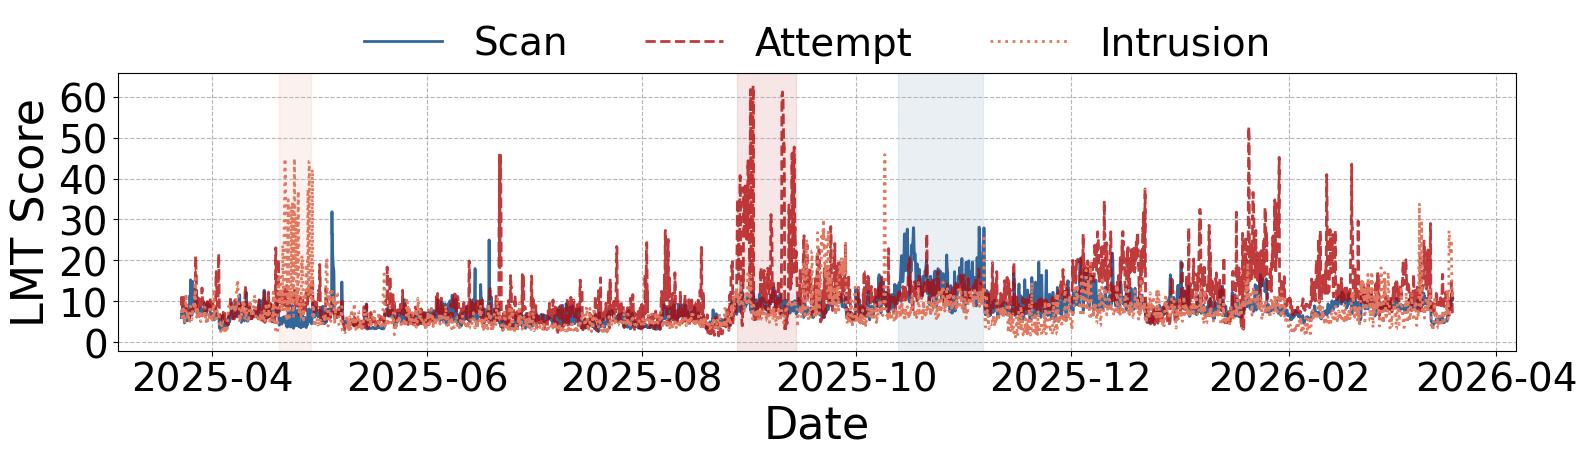

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Load ===
df = pd.read_csv("../data/rq3/h8/test_blocks.csv")

# convert block index → datetime
start_time = pd.Timestamp("2025-03-15 00:00:00")
df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === Style ===
font_main = 32
font_extra = 28
figsize = (16, 5)

color_attempt = "#B00A0B"
color_intrusion = "#E0795F" 
color_scan = "#34669A" 

# === Optional smoothing ===
window = 6
df["attempt_s"] = df["lmt_attempt_score"].rolling(window, center=True).median()
df["intrusion_s"] = df["lmt_intrusion-control_score"].rolling(window, center=True).median()
df["scan_s"] = df["lmt_scan_score"].rolling(window, center=True).median()

# === Plot ===
fig, ax = plt.subplots(figsize=figsize)

ax.plot(
    df["datetime"],
    df["scan_s"],
    color=color_scan,
    linewidth=2.0,
    label="Scan",
)

ax.plot(
    df["datetime"],
    df["attempt_s"],
    color=color_attempt,
    linewidth=2.0,
    linestyle="--",
    label="Attempt",
    alpha=0.8
)

ax.plot(
    df["datetime"],
    df["intrusion_s"],
    color=color_intrusion,
    linewidth=2.0,
    linestyle=":",
    label="Intrusion",
)

# === Shaded event windows ===
def add_window(ax, start, end, color, alpha=0.1):
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        color=color,
        alpha=alpha
    )

# Intrusion (late April)
add_window(ax, "2025-04-20", "2025-04-29", color_intrusion)

# Attempt (late Aug → early Sep)
add_window(ax, "2025-08-28", "2025-09-14", color_attempt)

# Scan (Oct core cluster)
add_window(ax, "2025-10-13", "2025-11-06", color_scan)

# Intrusion (late Jan)
#add_window(ax, "2026-01-19", "2026-01-29", color_intrusion)

# === Labels and styling ===
ax.set_ylabel("LMT Score", fontsize=font_main)
ax.set_xlabel("Date", fontsize=font_main)

ax.grid(alpha=0.9, linestyle="--")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=3,
    frameon=False,
    fontsize=font_extra
)

# x-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=0, fontsize=font_extra)
plt.yticks(fontsize=font_extra)

plt.tight_layout()

plt.savefig("lmt_inclass_evolution.pdf", bbox_inches="tight")
plt.show()

### Case Studies

##### Identify the corresponding files

In [7]:
import pandas as pd
from pathlib import Path

# =========================
# Load block metadata
# =========================
test_blocks = pd.read_csv("../data/rq3/h8/test_blocks.csv")
reference_blocks = pd.read_csv("../data/rq3/h8/reference_blocks.csv")

start_time = pd.Timestamp("2025-03-15 00:00:00")

test_blocks["datetime"] = start_time + pd.to_timedelta(test_blocks["block_index"], unit="h")

# reference_blocks may not have block_index, so recover datetime from file path if needed
def file_to_datetime(filepath):
    filepath = Path(filepath)
    date_str = filepath.parts[-2]                      # e.g. 2025-04-12
    fname = filepath.stem                              # e.g. window_23_00_00_00
    parts = fname.split("_")
    hour = int(parts[1])                               # first hour in filename
    return pd.Timestamp(f"{date_str} {hour:02d}:00:00")

reference_blocks["datetime"] = reference_blocks["file"].apply(file_to_datetime)

# =========================
# Define event windows
# =========================
EVENTS = {
    "intrusion_apr": {
        "start": "2025-04-20 00:00:00",
        "end":   "2025-04-29 23:59:59",
        "score_col": "lmt_intrusion-control_score",
    },
    "attempt_sep": {
        "start": "2025-08-28 00:00:00",
        "end":   "2025-09-14 23:59:59",
        "score_col": "lmt_attempt_score",
    },
    "scan_oct_nov": {
        "start": "2025-10-13 00:00:00",
        "end":   "2025-11-06 23:59:59",
        "score_col": "lmt_scan_score",
    },
    "intrusion_jan": {
        "start": "2026-01-19 00:00:00",
        "end":   "2026-01-29 23:59:59",
        "score_col": "lmt_intrusion-control_score",
    },
}

# =========================
# Helper
# =========================
def collect_event_and_reference(test_df, ref_df, event_name, start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    # test blocks inside the event window
    event_blocks = test_df[(test_df["datetime"] >= start) & (test_df["datetime"] <= end)].copy()

    # retrain ids active during this event
    retrain_ids = sorted(event_blocks["retrain_id"].dropna().astype(int).unique().tolist())

    # matching reference blocks
    ref_blocks = ref_df[ref_df["retrain_id"].isin(retrain_ids)].copy()

    return {
        "event_name": event_name,
        "event_blocks": event_blocks,
        "reference_blocks": ref_blocks,
        "retrain_ids": retrain_ids,
        "event_files": event_blocks["file"].drop_duplicates().tolist(),
        "reference_files": ref_blocks["file"].drop_duplicates().tolist(),
    }

# =========================
# Collect all cases
# =========================
cases = {}

for name, cfg in EVENTS.items():
    cases[name] = collect_event_and_reference(
        test_blocks,
        reference_blocks,
        name,
        cfg["start"],
        cfg["end"],
    )

# =========================
# Print quick summary
# =========================
for name, bundle in cases.items():
    print(f"\n=== {name} ===")
    print("Retrain IDs:", bundle["retrain_ids"])
    print("Event blocks:", len(bundle["event_blocks"]))
    print("Reference blocks:", len(bundle["reference_blocks"]))
    print("Event files:", len(bundle["event_files"]))
    print("Reference files:", len(bundle["reference_files"]))
    print("Event range:",
          bundle["event_blocks"]["datetime"].min(),
          "->",
          bundle["event_blocks"]["datetime"].max())


=== intrusion_apr ===
Retrain IDs: [10, 11, 12, 13]
Event blocks: 240
Reference blocks: 768
Event files: 240
Reference files: 423
Event range: 2025-04-20 00:00:00 -> 2025-04-29 23:00:00

=== attempt_sep ===
Retrain IDs: [42, 43]
Event blocks: 432
Reference blocks: 384
Event files: 432
Reference files: 324
Event range: 2025-08-28 00:00:00 -> 2025-09-14 23:00:00

=== scan_oct_nov ===
Retrain IDs: [54, 55]
Event blocks: 600
Reference blocks: 384
Event files: 600
Reference files: 384
Event range: 2025-10-13 00:00:00 -> 2025-11-06 23:00:00

=== intrusion_jan ===
Retrain IDs: [68, 69, 70, 71, 72]
Event blocks: 264
Reference blocks: 960
Event files: 264
Reference files: 441
Event range: 2026-01-19 00:00:00 -> 2026-01-29 23:00:00


In [8]:
def load_raw_blocks(file_list):
    dfs = []
    for f in file_list:
        try:
            dfs.append(pd.read_csv(f))
        except Exception as e:
            print(f"Failed to read {f}: {e}")
    if len(dfs) == 0:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

raw_cases = {}

for name, bundle in cases.items():
    event_raw = load_raw_blocks(bundle["event_files"])
    ref_raw = load_raw_blocks(bundle["reference_files"])

    raw_cases[name] = {
        "event_raw": event_raw,
        "reference_raw": ref_raw,
    }

    print(f"\n{name}")
    print("event raw shape:", event_raw.shape)
    print("reference raw shape:", ref_raw.shape)


intrusion_apr
event raw shape: (1140367, 25)
reference raw shape: (4136861, 25)

attempt_sep
event raw shape: (3064651, 25)
reference raw shape: (2635225, 25)


/tmp/ipykernel_3059616/2083930255.py:5: DtypeWarning: Columns (4,13,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))



scan_oct_nov
event raw shape: (3475864, 25)
reference raw shape: (2408691, 25)


/tmp/ipykernel_3059616/2083930255.py:5: DtypeWarning: Columns (4,13,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))



intrusion_jan
event raw shape: (2517809, 25)
reference raw shape: (4851401, 25)


##### Helpers to load daily files

In [9]:
import pandas as pd
from pathlib import Path

DAILY_DIR = Path("../data/daily")

def make_daily_file(day):
    day = pd.Timestamp(day).strftime("%Y-%m-%d")
    return DAILY_DIR / f"http_day_{day}.csv"

def date_range_list(start, end):
    return pd.date_range(start=start, end=end, freq="D").strftime("%Y-%m-%d").tolist()

def load_daily_range(start, end, usecols=None):
    days = date_range_list(start, end)
    dfs = []

    for day in days:
        f = make_daily_file(day)
        if f.exists():
            try:
                df = pd.read_csv(f, usecols=usecols)
                df["source_day"] = day
                dfs.append(df)
            except Exception as e:
                print(f"Failed to read {f}: {e}")
        else:
            print(f"Missing file: {f}")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)

    if "startTime" in out.columns:
        out["startTime"] = pd.to_datetime(out["startTime"], errors="coerce")

    if "endTime" in out.columns:
        out["endTime"] = pd.to_datetime(out["endTime"], errors="coerce")

    return out

In [10]:
CATEGORY_MAP = {
    "attempt": "attempt",
    "scan": "scan",
    "intrusion": "intrusion-control",
}

### Event windows and reference ranges

In [11]:
CASES = {
    "intrusion_apr": {
        "event_start": "2025-04-20",
        "event_end": "2025-04-29",
        "category": CATEGORY_MAP["intrusion"],
        "reference_ranges": [
            ("2025-04-12", "2025-04-20"),
            ("2025-04-14", "2025-04-22"),
            ("2025-04-14", "2025-04-22"),
        ],
    },
    "attempt_sep": {
        "event_start": "2025-08-28",
        "event_end": "2025-09-14",
        "category": CATEGORY_MAP["attempt"],
        "reference_ranges": [
            ("2025-08-19", "2025-08-27"),
            ("2025-08-25", "2025-09-02"),
        ],
    },
    "scan_oct_nov": {
        "event_start": "2025-10-13",
        "event_end": "2025-11-06",
        "category": CATEGORY_MAP["scan"],
        "reference_ranges": [
            ("2025-10-03", "2025-10-11"),
        ],
    },
    "intrusion_jan": {
        "event_start": "2026-01-19",
        "event_end": "2026-01-29",
        "category": CATEGORY_MAP["intrusion"],
        "reference_ranges": [
            ("2026-01-17", "2026-01-25"),
            ("2026-01-19", "2026-01-26"),
            ("2026-01-27", "2026-02-04"),
        ],
    },
}

In [12]:
def expand_reference_days(reference_ranges):
    days = set()
    for start, end in reference_ranges:
        days.update(date_range_list(start, end))
    return sorted(days)

def load_days(day_list, usecols=None):
    dfs = []
    for day in day_list:
        f = make_daily_file(day)
        if f.exists():
            try:
                df = pd.read_csv(f, usecols=usecols)
                df["source_day"] = day
                dfs.append(df)
            except Exception as e:
                print(f"Failed to read {f}: {e}")
        else:
            print(f"Missing file: {f}")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)

    if "startTime" in out.columns:
        out["startTime"] = pd.to_datetime(out["startTime"], errors="coerce")

    if "endTime" in out.columns:
        out["endTime"] = pd.to_datetime(out["endTime"], errors="coerce")

    return out

def load_case_raw(case_cfg):
    usecols = [
        "protocol", "category", "id", "http_method", "http_status", "http_uri",
        "http_body", "http_accept", "http_accept_encoding", "http_user_agent",
        "http_content_type", "http_referer", "http_connection",
        "startTime", "endTime", "clientIP", "client_asn", "client_as_org",
        "client_country", "hostIP", "host_asn", "host_as_org", "host_country"
    ]

    event_raw = load_daily_range(
        case_cfg["event_start"],
        case_cfg["event_end"],
        usecols=usecols
    )

    ref_days = expand_reference_days(case_cfg["reference_ranges"])
    reference_raw = load_days(ref_days, usecols=usecols)

    cat = case_cfg["category"]

    event_raw = event_raw[event_raw["category"] == cat].copy()
    reference_raw = reference_raw[reference_raw["category"] == cat].copy()

    return event_raw, reference_raw

In [13]:
raw_cases = {}

for name, cfg in CASES.items():
    event_raw, reference_raw = load_case_raw(cfg)
    raw_cases[name] = {
        "event_raw": event_raw,
        "reference_raw": reference_raw,
    }

    print(f"\n=== {name} ===")
    print("event shape:", event_raw.shape)
    print("reference shape:", reference_raw.shape)
    print("event days:", cfg["event_start"], "to", cfg["event_end"])
    print("reference day count:", len(expand_reference_days(cfg["reference_ranges"])))
    print("category:", cfg["category"])


=== intrusion_apr ===
event shape: (1912105, 24)
reference shape: (2212559, 24)
event days: 2025-04-20 to 2025-04-29
reference day count: 11
category: intrusion-control


/tmp/ipykernel_3059616/2443507955.py:21: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=usecols)
/tmp/ipykernel_3059616/107464803.py:13: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=usecols)



=== attempt_sep ===
event shape: (1489046, 24)
reference shape: (1884681, 24)
event days: 2025-08-28 to 2025-09-14
reference day count: 15
category: attempt

=== scan_oct_nov ===
event shape: (949017, 24)
reference shape: (427460, 24)
event days: 2025-10-13 to 2025-11-06
reference day count: 9
category: scan

=== intrusion_jan ===
event shape: (1041631, 24)
reference shape: (1682778, 24)
event days: 2026-01-19 to 2026-01-29
reference day count: 19
category: intrusion-control


### Comparison
**New patterns** that did not exist in reference   
**Amplified patterns** that existed but suddenly dominate   
**Structural shifts** in behaviour such as concentration or repetition  

In [14]:
from collections import Counter
import pandas as pd
import numpy as np

def safe_value_counts(series, topk=20):
    vc = series.value_counts(dropna=True)
    return vc.head(topk), vc

def normalize_counts(vc):
    total = vc.sum()
    if total == 0:
        return vc
    return vc / total

def compare_feature(event, reference, col, topk=20):
    e_top, e_all = safe_value_counts(event[col], topk)
    r_top, r_all = safe_value_counts(reference[col], topk)

    e_norm = normalize_counts(e_all)
    r_norm = normalize_counts(r_all)

    # align index
    all_keys = set(e_all.index).union(set(r_all.index))

    rows = []
    for k in all_keys:
        e = e_norm.get(k, 0)
        r = r_norm.get(k, 0)
        diff = e - r
        ratio = (e + 1e-9) / (r + 1e-9)

        rows.append((k, e, r, diff, ratio))

    df = pd.DataFrame(rows, columns=["value", "event", "reference", "diff", "ratio"])

    # sort by strongest change
    df = df.sort_values(by="diff", ascending=False)

    return df.head(topk), df

In [15]:
uri_top, uri_full = compare_feature(
    event_raw,
    reference_raw,
    col="http_uri",
    topk=1000
)

print(uri_top.head(10))
uri_top.to_csv("../data/case/top_uri_com.csv")

                       value     event  reference      diff     ratio
8681   /wp-comments-post.php  0.004810   0.003027  0.001783  1.588882
66130            /xmlrpc.php  0.008413   0.007608  0.000805  1.105742
28164     /.aws/credentials/  0.001250   0.000921  0.000329  1.357914
15462                   /api  0.002822   0.002499  0.000323  1.129137
15032            /api/action  0.000847   0.000524  0.000323  1.615521
35523               /swagger  0.003143   0.002824  0.000319  1.112817
61526              /swagger/  0.003178   0.002863  0.000315  1.109875
19217   /index.php?s=captcha  0.000966   0.000669  0.000297  1.443352
22398      /.aws/credentials  0.001242   0.000990  0.000252  1.254793
32077     /service/api-docs/  0.000921   0.000670  0.000250  1.373480


In [16]:
new_uris = set(event_raw["http_uri"]) - set(reference_raw["http_uri"])

In [17]:
method_top, _ = compare_feature(
    event_raw,
    reference_raw,
    col="http_method"
)

print(method_top)

       value         event     reference          diff     ratio
7        GET  9.031538e-01  8.833732e-01  1.978060e-02  1.022392
11      HEAD  9.446723e-03  8.606007e-03  8.407160e-04  1.097689
5   ZSDLKFJ2  1.338286e-03  1.192076e-03  1.462094e-04  1.122651
9        PUT  1.432369e-03  1.358468e-03  7.390108e-05  1.054400
6      PURGE  0.000000e+00  5.942555e-07 -5.942555e-07  0.001680
1      DEBUG  0.000000e+00  5.942555e-07 -5.942555e-07  0.001680
0   POSTPOST  9.600329e-07  4.159788e-06 -3.199755e-06  0.230974
2    CONNECT  4.800164e-06  8.319576e-06 -3.519412e-06  0.577023
10   OPTIONS  3.225710e-04  3.310003e-04 -8.429242e-06  0.974534
8      PATCH  2.784095e-05  4.100363e-05 -1.316267e-05  0.678995
4     DELETE  3.552122e-05  1.907560e-04 -1.552348e-04  0.186217
3       POST  8.423712e-02  1.048938e-01 -2.065669e-02  0.803070
